# SL-12b : Synthèse logique spectrale — Fourier booléen et poids ternaires

**Phase 5 -- Neuro-symbolique** | Précédent : [SL-12 (difflogic, portes locales)](SL-12-DifferentiableLogicGateNetworks.ipynb) --> SL-12b --> Suivant : [SL-11 (capstone pipeline)](SL-11-Capstone-NeuroSymbolic.ipynb) | [Index de la série](README.md)

SL-12 apprenait des **circuits de portes logiques locales** (difflogic, Petersen 2022). Ce notebook explore l'autre registre de la synthèse logique neuro-symbolique : la **synthèse spectrale**, où une fonction booléenne est représentée globalement dans la **base de Walsh-Hadamard**, approchée par des **poids ternaires** $\{-1,0,+1\}$, composée par un **routage de Sinkhorn**, puis raffinée par une **recherche discrète** (MCMC, parallel tempering).

Basé sur Gorgi Pavlov, *Differentiable Logic Synthesis: Spectral Coefficient Selection via Sinkhorn-Constrained Composition* ([arXiv:2601.13953](https://arxiv.org/abs/2601.13953)), digéré dans l'EPIC #14366 (grain G2) et confronté au matériel existant de la série.

**Statuts de preuve** — convention utilisée dans toute la prose de ce notebook :

| Étiquette | Signification |
|---|---|
| *[vérifié ici]* | Mesuré/exécuté dans ce notebook (sorties réelles committées) |
| *[papier]* | Rapporté par Pavlov (arXiv:2601.13953), non re-vérifié ici |
| *[artefact/EPIC]* | Constat mesuré sur l'artefact `gogipav14/spectral-llm`, rapporté dans l'EPIC #14366 (lecture G1) |

Exécution CPU uniquement : `numpy` + `matplotlib`, aucune ressource externe. Durée estimée : ~75 minutes.

## Motivation — deux registres pour la synthèse logique différentiable

SL-12 (difflogic) et SL-12b (spectral) répondent à la même question — *comment apprendre une fonction booléenne exacte par descente de gradient, puis se discrétiser sans perdre la fonction ?* — avec deux objets appris radicalement différents :

| Aspect | SL-12 — difflogic | SL-12b — spectral (ce notebook) |
|---|---|---|
| Unité apprise | une **porte locale** parmi 16 (AND, OR, XOR, ...), 2 entrées | des **poids globaux** sur des caractères de Walsh $\chi_S$ (fonctions de toute l'entrée) |
| Câblage | **fixe** (connexions aléatoires figées à l'initialisation) | **composition** de sous-fonctions apprises, routée par relaxation bistochastique (Sinkhorn) |
| Discrétisation | argmax des probabilités de portes | **quantification** des poids vers $\{-1,0,+1\}$ puis **recherche discrète** |
| Objet final | circuit booléen interprétable-par-construction | polynôme de seuil ternaire (PTF) : $\mathrm{sign}\big(\sum_S w_S\,\chi_S(x)\big)$ |
| Garanties | entraînements empiriques (MNIST) *[papier]* | représentabilité prouvée computationnellement jusqu'à $n \le 4$, **conjecture ouverte** au-delà *[papier]* |

**Pourquoi ce second registre mérite un notebook** : la base de Walsh est l'orthonormalisation *exacte* de l'espace des fonctions booléennes — chaque fonction y a une représentation unique et reconstructible. La question pédagogique centrale devient : *en quoi les coefficients Fourier exacts et les poids ternaires d'une PTF sont-ils des objets différents ?* (Section 2). La réponse éclaire ce que la quantification détruit et ce que la recherche discrète répare.

**Limites vérifiées, portées par le livrable** *[artefact/EPIC]* : le smoke test officiel Phase 1 de l'artefact termine à 6/7 (labels AND/OR et XOR/XNOR incohérents avec les tables effectivement produites) ; l'entraînement Phase 2 exécuté sur CPU atteint 87,52 % de moyenne mais laisse `xor_of_and_with_b` à 50,63 % ; sur l'oracle $n=16$, Sinkhorn n'améliore pas le débruitage. Ces constats bornent ce que le pipeline spectral réalise en pratique — ce notebook enseigne les mécanismes, pas le discours marketing.

## Plan

1. **Convention booléenne** : encodage $\{0,1\} \leftrightarrow \{-1,+1\}$ écrit une seule fois, testé par tables exhaustives
2. **Caractères de Walsh** : coefficients exacts, FWHT en $O(n\,2^n)$, reconstruction exacte, Parseval, spectres de fonctions connues, benchmark
3. **Exercice 1** : le spectre d'une fonction « compteur » (exactement deux vrais parmi quatre)
4. **Coefficients Fourier exacts contre poids PTF ternaires** : énumération exhaustive sur $n=2$ ; ce que la quantification naïve casse
5. **Routage de Sinkhorn** : relaxation bistochastique, métrique de permutation, ex æquos — sans surclaim
6. **Exercice 2** : une autre géométrie d'ex æquos
7. **Quantification + recherche discrète** : oracle exact de Hamming, greedy, Metropolis, parallel tempering — à budget d'évaluations égal
8. **Exercice 3** : chercher une instance qui sépare SA et PT
9. **Pont avec SL-12** : un circuit de portes locales vu dans la base de Walsh ; synthèse comparative

## 0. La convention booléenne, écrite une seule fois

Tout ce notebook repose sur une convention unique, validée par test exhaustif dans la cellule suivante :

- **Encodage** : un bit $b \in \{0,1\}$ devient un signe $x = 2b - 1$. Ainsi $\text{Vrai}(1) \leftrightarrow +1$ et $\text{Faux}(0) \leftrightarrow -1$ — pour les entrées **et** les sorties.
- **Tables de vérité** : la ligne d'index $i$ énumère les bits de $i$ (variable $x_k$ = bit $k$ de $i$) ; la ligne 0 est « tout Faux ».
- **Caractères de Walsh** : $\chi_S(x) = \prod_{k \in S} x_k$, avec $\chi_\emptyset \equiv 1$.
- **Seuil** : $\mathrm{sign}(0) = +1$ (convention déclarée une fois, utilisée partout — elle compte dans les représentations PTF de la Section 2).

L'incohérence de convention est le premier piège du domaine : l'artefact officiel de Pavlov livre un smoke test à 6/7 précisément parce que ses labels AND/OR et XOR/XNOR ne correspondent pas aux tables produites sous sa convention déclarée *[artefact/EPIC]*. Le test ci-dessous croise les définitions **au niveau bit** (`&, |, ^`) et **au niveau signe** (formules de portes) : les quatre tables doivent coïncider exactement.

In [1]:
# Imports, versions, et test de convention (tables exhaustives sur {-1,+1}^2)
import itertools
import statistics
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"numpy {np.__version__} | matplotlib {matplotlib.__version__}")

# ---- Convention : Vrai(1) <=> +1 ; x = 2b - 1 ----
to_sign = lambda b: 2 * np.asarray(b, dtype=np.int64) - 1
to_bit = lambda x: (np.asarray(x, dtype=np.int64) + 1) // 2
sign0 = lambda z: np.where(np.asarray(z) >= 0, 1, -1)  # seuil declare : sign(0) = +1

def input_matrix(n):
    """Lignes = points de {-1,+1}^n ; ligne i : variable x_k = bit k de i (ligne 0 = tout Faux)."""
    idx = np.arange(2 ** n)
    bits = (idx[:, None] >> np.arange(0, n)) & 1
    return to_sign(bits)

# Portes definies DIRECTEMENT sur les signes
g_AND = lambda x, y: sign0(x + y - 1)   # +1 ssi les deux entrees valent +1
g_OR = lambda x, y: sign0(x + y + 1)    # +1 ssi au moins une entree vaut +1
g_XOR = lambda x, y: -x * y             # +1 ssi exactement une entree vaut +1
g_XNOR = lambda x, y: x * y             # +1 ssi les deux entrees sont egales

# Test croise : definition au niveau BIT contre definition au niveau SIGNE
X2 = input_matrix(2)
b1, b2 = to_bit(X2[:, 0]), to_bit(X2[:, 1])
for nom, f_bits, f_signes in [
    ("AND", to_sign(b1 & b2), g_AND(X2[:, 0], X2[:, 1])),
    ("OR", to_sign(b1 | b2), g_OR(X2[:, 0], X2[:, 1])),
    ("XOR", to_sign(b1 ^ b2), g_XOR(X2[:, 0], X2[:, 1])),
    ("XNOR", to_sign(1 - (b1 ^ b2)), g_XNOR(X2[:, 0], X2[:, 1])),
]:
    ok = np.array_equal(f_bits, f_signes)
    print(f"{nom:4s}: bits->signes {f_bits.tolist()}  |  portes-signes {f_signes.tolist()}  |  {'OK' if ok else 'ECHEC'}")
    assert ok, f"convention cassee sur {nom}"
print("Convention validee : les 4 tables exhaustives coincident.")

numpy 2.4.4 | matplotlib 3.10.8
AND : bits->signes [-1, -1, -1, 1]  |  portes-signes [-1, -1, -1, 1]  |  OK
OR  : bits->signes [-1, 1, 1, 1]  |  portes-signes [-1, 1, 1, 1]  |  OK
XOR : bits->signes [-1, 1, 1, -1]  |  portes-signes [-1, 1, 1, -1]  |  OK
XNOR: bits->signes [1, -1, -1, 1]  |  portes-signes [1, -1, -1, 1]  |  OK
Convention validee : les 4 tables exhaustives coincident.


### Lecture du test de convention

**Sortie obtenue** : les quatre tables (AND, OR, XOR, XNOR) coïncident exactement entre le monde des bits (`&, |, ^`) et le monde des signes (formules de portes).

| Aspect | Valeur | Signification |
|---|---|---|
| Tables validées | 4/4 | l'encodage `Vrai <=> +1` est cohérent d'un bout à l'autre |
| `XOR` sur signes | `-x*y` | la parité n'est **pas** un produit nu : le signe moins distingue XOR de XNOR |
| Coût du test | 4 lignes | exactement le test dont l'artefact Pavlov aurait eu besoin *[artefact/EPIC]* |

> **Note technique** : la distinction XOR/XNOR est le piège le plus fréquent du domaine — l'auteur de ce notebook l'a commise en prototypant la Section 1 (formule écrite pour « XOR3 » qui produisait la table de la parité paire). Le test de convention attrape ce genre d'erreur avant qu'elle ne contamine les spectres ; c'est la leçon opérationnelle du constat 6/7 de l'artefact *[artefact/EPIC]*.

## 1. Caractères de Walsh et transformée exacte

L'espace des fonctions $f : \{-1,+1\}^n \to \mathbb{R}$ est de dimension $2^n$, et la famille des **caractères** $\{\chi_S\}_{S \subseteq [n]}$ en est une base **orthonormée** pour le produit scalaire $\langle f, g \rangle = 2^{-n} \sum_x f(x)\, g(x)$ :

$$
\hat f(S) = \langle f, \chi_S \rangle = \frac{1}{2^n} \sum_{x} f(x)\, \chi_S(x),
\qquad
f(x) = \sum_{S \subseteq [n]} \hat f(S)\, \chi_S(x).
$$

Trois conséquences exactes, vérifiées numériquement dans la cellule suivante :

1. **Reconstruction exacte** — la somme des coefficients redonne la table de vérité sans erreur ;
2. **Parseval** — pour $f$ à valeurs $\pm 1$ : $\sum_S \hat f(S)^2 = 1$ (l'énergie est conservée) ;
3. **FWHT** — le calcul de *tous* les coefficients se fait en $O(n\,2^n)$ par l'algorithme **papillon** (transformée de Walsh-Hadamard rapide), contre $O(4^n)$ pour la somme naïve.

**Détail d'implémentation honnête** : le papillon calcule la matrice de Sylvester $H_{ij} = (-1)^{\mathrm{popcount}(i \wedge j)}$. Sous notre convention (`Vrai <=> +1`), le caractère en colonne $j$ vaut $\chi_{S_j} = (-1)^{|S_j|} \cdot H_{\cdot,j}$ — un facteur de signe par colonne. La cellule **teste** l'égalité naïf/papillon sur des fonctions aléatoires plutôt que de la supposer : c'est ce test qui a attrapé une inversion de convention de bits pendant le prototypage de ce notebook.

In [2]:
# Coefficients de Walsh : somme naive, papillon FWHT, reconstruction, Parseval
def subsets_by_index(n):
    """Colonne j : la variable k+1 appartient a S_j ssi le bit k de j vaut 1 (coherent avec input_matrix)."""
    return [tuple(np.arange(1, n + 1)[(((j >> np.arange(0, n)) & 1)).astype(bool)].tolist())
            for j in range(2 ** n)]

def subset_labels(n):
    """Etiquettes compactes des sous-ensembles, dans l'ordre des indices de transformee."""
    return ["vide" if not S else "{" + ",".join(map(str, S)) + "}" for S in subsets_by_index(n)]

def char_matrix(n):
    """Table des caracteres chi_S par produits explicites (verite terrain, O(4^n))."""
    X = input_matrix(n)
    C = np.ones((2 ** n, 2 ** n), dtype=np.int64)
    for j, S in enumerate(subsets_by_index(n)):
        for k in S:
            C[:, j] *= X[:, k - 1]
    return C

def walsh_naive(f, n):
    """Coefficients exacts par somme directe."""
    return char_matrix(n).T @ f / (2 ** n)

def fwht(v):
    """Transformee de Walsh-Hadamard iterative (papillon), O(n 2^n), ordre de Sylvester."""
    y = np.asarray(v, dtype=np.float64).copy()
    h = 1
    while h < len(y):
        for i in range(0, len(y), 2 * h):
            a, b = y[i:i + h].copy(), y[i + h:i + 2 * h].copy()
            y[i:i + h], y[i + h:i + 2 * h] = a + b, a - b
        h *= 2
    return y

def walsh_fwht(f, n):
    """Coefficients via papillon : chi_{S_j} = (-1)^|S_j| * colonne j de Sylvester."""
    D = np.array([(-1.0) ** bin(j).count("1") for j in range(2 ** n)])
    return D * fwht(f) / (2 ** n)

def reconstruct(fhat, n):
    """f = C fhat = H (D fhat) -- sans division, car H H = 2^n I."""
    D = np.array([(-1.0) ** bin(j).count("1") for j in range(2 ** n)])
    return fwht(D * fhat)

def spectre_degre(fhat):
    """Degre Fourier exact = taille du plus grand sous-ensemble a coefficient non nul."""
    pc = np.array([bin(j).count("1") for j in range(len(fhat))])
    nz = np.nonzero(np.abs(fhat) > 1e-12)[0]
    return int(pc[nz].max()) if len(nz) else 0

# Tests : naive == papillon, reconstruction exacte -- sur 15 fonctions aleatoires
rng_test = np.random.default_rng(42)
for n in (2, 3, 4):
    for _ in range(5):
        f = rng_test.choice([-1, 1], size=2 ** n)
        assert np.allclose(walsh_naive(f, n), walsh_fwht(f, n), atol=1e-10)
        assert np.allclose(reconstruct(walsh_fwht(f, n), n), f, atol=1e-10)
print("Tests passes : naive == papillon et reconstruction exacte (15 fonctions aleatoires, n = 2, 3, 4)")

# Spectres de fonctions connues sur n = 3
X3 = input_matrix(3)
b3 = to_bit(X3)
MAJ3 = sign0(X3[:, 0] + X3[:, 1] + X3[:, 2])             # majorite (n impair : seuil jamais nul)
PARITE3 = to_sign(np.sum(b3, axis=1) % 2)                 # parite definie au niveau BIT...
ET3 = g_AND(g_AND(X3[:, 0], X3[:, 1]), X3[:, 2])         # ET a 3 entrees
OU3 = g_OR(g_OR(X3[:, 0], X3[:, 1]), X3[:, 2])           # OU a 3 entrees
assert np.array_equal(PARITE3, X3[:, 0] * X3[:, 1] * X3[:, 2])  # ...egale au produit des signes

labs3 = subset_labels(3)
print(f"\n{'fonction':9s} {'degre':>5s} {'Parseval':>8s}  coefficients non nuls")
for nom, f in [("MAJ3", MAJ3), ("PARITE3", PARITE3), ("ET3", ET3), ("OU3", OU3)]:
    c = walsh_fwht(f, 3)
    nz = ", ".join(f"chi_{labs3[j]}={c[j]:+.2f}" for j in range(8) if abs(c[j]) > 1e-12)
    assert np.max(np.abs(reconstruct(c, 3) - f)) < 1e-10 and abs(np.sum(c ** 2) - 1) < 1e-10
    print(f"{nom:9s} {spectre_degre(c):5d} {np.sum(c ** 2):8.4f}  {nz}")
print("\nReconstruction max-erreur < 1e-10 et Parseval = 1 verifies sur les 4 fonctions.")

Tests passes : naive == papillon et reconstruction exacte (15 fonctions aleatoires, n = 2, 3, 4)

fonction  degre Parseval  coefficients non nuls
MAJ3          3   1.0000  chi_{1}=+0.50, chi_{2}=+0.50, chi_{3}=+0.50, chi_{1,2,3}=-0.50
PARITE3       3   1.0000  chi_{1,2,3}=+1.00
ET3           3   1.0000  chi_vide=-0.75, chi_{1}=+0.25, chi_{2}=+0.25, chi_{1,2}=+0.25, chi_{3}=+0.25, chi_{1,3}=+0.25, chi_{2,3}=+0.25, chi_{1,2,3}=+0.25
OU3           3   1.0000  chi_vide=+0.75, chi_{1}=+0.25, chi_{2}=+0.25, chi_{1,2}=-0.25, chi_{3}=+0.25, chi_{1,3}=-0.25, chi_{2,3}=-0.25, chi_{1,2,3}=+0.25

Reconstruction max-erreur < 1e-10 et Parseval = 1 verifies sur les 4 fonctions.


### Lecture des spectres

**Sortie obtenue** : quatre fonctions de $\{-1,+1\}^3$, chacune reconstruite exactement, Parseval = 1.

| Fonction | Degré exact | Coefficients non nuls | Lecture |
|---|---|---|---|
| MAJ3 | 3 | $\hat f(\{k\}) = +0{,}5$ (trois fois), $\hat f(\{1,2,3\}) = -0{,}5$ | la majorité **est** le polynôme exact $\frac{1}{2}(x_1 + x_2 + x_3 - x_1x_2x_3)$ |
| PARITE3 | 3 | un seul : $\hat f(\{1,2,3\}) = +1$ | la parité **est** un caractère unique — tout le spectre tient sur un coefficient |
| ET3 | 3 | les 8 coefficients, en quarts | aucune structure simple : tout l'espace est mobilisé |
| OU3 | 3 | les 8 coefficients, signes alternés | miroir du ET (OU = NON-ET des négations) |

**Points clés** :

1. Le **degré Fourier exact** des quatre fonctions est 3 (le maximum) — alors même que MAJ3 s'évalue par un simple seuil linéaire `sign(x1+x2+x3)`. Ce paradoxe est le pivot de la Section 2.
2. La parité est le cas extrême de **sparsité spectrale** : 1 coefficient non nul sur 8.
3. Ces valeurs sont les sorties réelles de la cellule ci-dessus — la table les cite, elle ne les remplace pas.

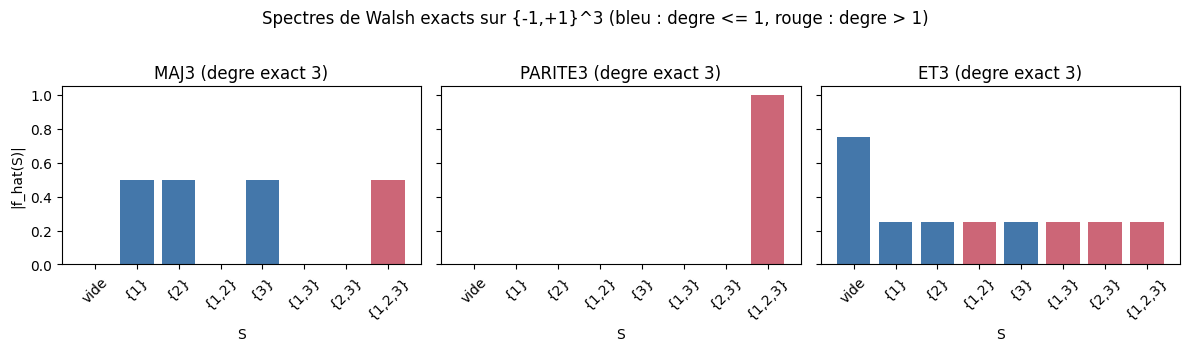

In [3]:
# Figure : les spectres cote a cote (|coefficients| par sous-ensemble)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
degs3 = [bin(j).count("1") for j in range(8)]
for ax, (nom, f) in zip(axes, [("MAJ3", MAJ3), ("PARITE3", PARITE3), ("ET3", ET3)]):
    c = walsh_fwht(f, 3)
    couleurs = ["#4477aa" if d <= 1 else "#cc6677" for d in degs3]
    ax.bar(range(8), np.abs(c), color=couleurs)
    ax.set_xticks(range(8))
    ax.set_xticklabels(labs3, rotation=45)
    ax.set_title(f"{nom} (degre exact {spectre_degre(c)})")
    ax.set_xlabel("S")
axes[0].set_ylabel("|f_hat(S)|")
plt.suptitle("Spectres de Walsh exacts sur {-1,+1}^3 (bleu : degre <= 1, rouge : degre > 1)", y=1.02)
plt.tight_layout()
plt.show()

### Lecture de la figure

**Sortie obtenue** : trois diagrammes en barres des $|\hat f(S)|$ sur les 8 sous-ensembles de $\{1,2,3\}$.

- **MAJ3** : trois barres bleues à 0,5 (singletons) et une barre rouge à 0,5 (le triple) — la non-linéarité tient tout entière dans ce coefficient d'ordre 3.
- **PARITE3** : une seule barre rouge à 1,0 — le caractère $\chi_{\{1,2,3\}}$.
- **ET3** : huit barres non nulles, dont la constante ($\hat f(\emptyset) = -0{,}75$) domine — la fonction est « presque constante », et ce biais se lit directement dans le spectre.

La couleur distingue le degré $\le 1$ (combinaison linéaire seuillée) du degré $> 1$ : c'est la frontière que la Section 2 déplace en changeant de représentation.

  n  naive (s)  papillon (s)   rapport
  8      0.003       0.00050        5x


 10      0.048       0.00193       25x


 12      2.584       0.00811      318x
 16         --         0.118 (2^n = 65536 coefficients)


 18         --         0.550 (2^n = 262144 coefficients)


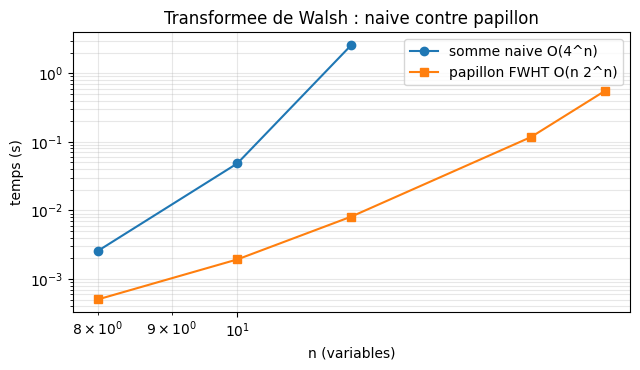

In [4]:
# Benchmark : somme naive O(4^n) contre papillon O(n 2^n)
rng_bench = np.random.default_rng(42)
print(f"{'n':>3s} {'naive (s)':>10s} {'papillon (s)':>13s} {'rapport':>9s}")
bench_naive, bench_fwht = [], []
for n in (8, 10, 12):
    f = rng_bench.choice([-1, 1], size=2 ** n)
    t0 = time.perf_counter()
    c1 = walsh_naive(f, n)
    t1 = time.perf_counter()
    c2 = walsh_fwht(f, n)
    t2 = time.perf_counter()
    assert np.allclose(c1, c2, atol=1e-8)
    bench_naive.append((n, t1 - t0))
    bench_fwht.append((n, t2 - t1))
    print(f"{n:3d} {t1 - t0:10.3f} {t2 - t1:13.5f} {(t1 - t0) / (t2 - t1):8.0f}x")
for n in (16, 18):
    f = rng_bench.choice([-1, 1], size=2 ** n)
    t0 = time.perf_counter()
    fwht(f)
    t1 = time.perf_counter()
    bench_fwht.append((n, t1 - t0))
    print(f"{n:3d} {'--':>10s} {t1 - t0:13.3f} (2^n = {2 ** n} coefficients)")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(*zip(*bench_naive), "o-", label="somme naive O(4^n)")
ax.loglog(*zip(*bench_fwht), "s-", label="papillon FWHT O(n 2^n)")
ax.set_xlabel("n (variables)")
ax.set_ylabel("temps (s)")
ax.set_title("Transformee de Walsh : naive contre papillon")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture du benchmark

**Sortie obtenue** : un tableau de temps et une figure log-log (les temps absolus dépendent de la machine ; les rapports et les pentes sont le contenu pédagogique).

| Lecture | Détail |
|---|---|
| Pentes mesurées | la courbe naïve grimbe de plusieurs ordres de grandeur quand $n$ passe de 8 à 12 (rapport mesuré dans le tableau) ; la courbe papillon reste quasi plate à l'échelle de la figure |
| Cause théorique | $4^n$ contre $n\,2^n$ : chaque variable supplémentaire **quadruple** le coût naïf mais seulement le **double** (à facteur $n$ près) pour le papillon |
| Conséquence pratique | le spectre exact d'une fonction de 18 variables ($2^{18} = 262\,144$ coefficients) se calcule en une fraction de seconde — c'est ce qui rend l'analyse spectrale utilisable comme oracle et comme outil de diagnostic |

> **Note** : la table des caractères naïve reste la **vérité terrain** utilisée par les tests d'égalité (cellule précédente) — lente mais indépendante de l'astuce du papillon.

### Exercice 1 — Le spectre du « exactement deux vrais parmi quatre »

La fonction $\text{EXACT2} : \{-1,+1\}^4 \to \{-1,+1\}$ vaut $+1$ ssi **exactement deux** des quatre entrées valent $+1$ (poids de Hamming exactement 2). C'est une fonction « compteur » : ni un simple seuil, ni une parité.

**Objectifs** : calculer son spectre exact, vérifier reconstruction et Parseval, mesurer son degré Fourier exact, puis déterminer — par énumération des $3^5 = 243$ vecteurs $(w_\emptyset, w_1, w_2, w_3, w_4)$ — si une **PTF ternaire de degré 1** la représente.

In [5]:
# Exercice 1 -- TODO etudiant :
# Etape 1 : construire EXACT2 sur n=4 :
#   b4 = to_bit(input_matrix(4))
#   EXACT2 = to_sign((np.sum(b4, axis=1) == 2).astype(int))
# Etape 2 : verifier walsh_naive(EXACT2, 4) == walsh_fwht(EXACT2, 4) et reconstruction exacte
# Etape 3 : lister les coefficients non nuls (indices subset_labels(4)), le degre exact, Parseval == 1
# Etape 4 : enumerer itertools.product([-1, 0, 1], repeat=5) et compter les vecteurs w tels que
#           sign0(A_deg1 @ w) == EXACT2, avec A_deg1 = colonnes des caracteres de degre <= 1
#           (construire A_deg1 comme la matrice A de la Section 4, mais avec |S| <= 1)
# Indice 1 : C(4,2) = 6 sous-ensembles de taille 2 -- le spectre d'EXACT2 est tres regulier
# Indice 2 : si le compte de l'etape 4 est nul, EXACT2 n'est pas un seuil lineaire ternaire --
#            comparez avec OR (Section 2), qui l'est.
resultat_ex1 = None  # TODO etudiant : remplacer par (degre_exact, parseval, nb_ptf_degre1)
print("Exercice 1 a completer -- spectre de EXACT2 et test PTF de degre 1.")

Exercice 1 a completer -- spectre de EXACT2 et test PTF de degre 1.


## 2. Coefficients Fourier exacts contre poids PTF ternaires

Une **fonction de seuil polynomiale** (PTF, *polynomial threshold function*) représente $f$ par des poids $w_S$ et un seuil implicite à zéro :

$$
f(x) = \mathrm{sign}\Big(\sum_{S} w_S\, \chi_S(x)\Big), \qquad \mathrm{sign}(0) = +1 \ \text{(convention déclarée en Section 0)}.
$$

Quand les poids sont restreints à $w_S \in \{-1, 0, +1\}$, on parle de **PTF ternaire** — l'objet que la synthèse spectrale de Pavlov cherche : des poids discrets, compacts, et une fonction booléenne exacte au sens du seuil *[papier]*.

**Les poids $w_S$ ne sont PAS les coefficients $\hat f(S)$**. Trois différences structurelles :

1. **Nature** : $\hat f(S)$ est une espérance rationnelle (multiple de $2^{-n}$), **unique**, définie par orthogonalité ; $w_S$ est un entier de choix, **non unique**, défini par une condition de seuil.
2. **Degré** : le degré de la PTF peut être **strictement inférieur** au degré Fourier exact — OU sur $n=2$ a un degré exact de 2 mais une PTF ternaire de degré 1 : $\mathrm{sign}(1 + x_1 + x_2)$.
3. **Non-unicité** : plusieurs vecteurs ternaires peuvent représenter la même fonction — la cellule suivante les compte.

À l'inverse, le polynôme Fourier exact **est toujours** une représentation de seuil de $f$ (puisque $\sum_S \hat f(S)\,\chi_S(x) = f(x) = \pm 1$), mais avec $2^n$ poids rationnels — la représentation la plus riche en information, pas la plus compacte.

La cellule suivante énumère **exhaustivement** les $3^4 = 81$ vecteurs ternaires de $n=2$ et croise, pour chacune des 16 fonctions booléennes : degré Fourier exact, degré PTF minimal, nombre de représentations minimales, exemple de poids.

In [6]:
# Enumeration exhaustive des PTF ternaires sur n=2 (3^4 = 81 vecteurs, 16 fonctions)
C2 = char_matrix(2)
pc2 = np.array([bin(j).count("1") for j in range(4)])

# Les 16 fonctions de {-1,+1}^2, nommees et definies sur les signes
x1, x2 = X2[:, 0], X2[:, 1]
NOMS2 = {
    "constante +1": np.ones(4, dtype=int),
    "constante -1": -np.ones(4, dtype=int),
    "x1": x1.copy(), "NON x1": -x1, "x2": x2.copy(), "NON x2": -x2,
    "AND": g_AND(x1, x2), "NAND": -g_AND(x1, x2),
    "OR": g_OR(x1, x2), "NOR": -g_OR(x1, x2),
    "XOR": g_XOR(x1, x2), "XNOR": g_XNOR(x1, x2),
    "x1 => x2": g_OR(-x1, x2), "NON(x1 => x2)": -g_OR(-x1, x2),
    "x2 => x1": g_OR(-x2, x1), "NON(x2 => x1)": -g_OR(-x2, x1),
}
assert len(set(map(tuple, NOMS2.values()))) == 16  # 16 noms, 16 fonctions distinctes

w_ternaires = list(itertools.product([-1, 0, 1], repeat=4))
labs2 = subset_labels(2)
print(f"{'fonction':15s} {'degFourier':>10s} {'degPTFmin':>9s} {'nbreps':>6s}  exemple w (vide, 1, 2, 12)")
for nom, f in NOMS2.items():
    cf = walsh_fwht(f, 2)
    assert np.array_equal(reconstruct(cf, 2), f)
    reps = []
    for w in w_ternaires:
        if np.array_equal(sign0(C2 @ np.array(w)), f):
            d = int(pc2[np.nonzero(w)[0]].max()) if any(w) else 0
            reps.append((d, w))
    dmin = min(r[0] for r in reps)
    nrep = sum(1 for r in reps if r[0] == dmin)
    ex = next(r[1] for r in reps if r[0] == dmin)
    print(f"{nom:15s} {spectre_degre(cf):10d} {dmin:9d} {nrep:6d}  {ex}")
print("\n(colonnes w dans l'ordre des indices :", ", ".join(f"chi_{l}" for l in labs2), ")")

fonction        degFourier degPTFmin nbreps  exemple w (vide, 1, 2, 12)
constante +1             0         0      2  (0, 0, 0, 0)
constante -1             0         0      1  (-1, 0, 0, 0)
x1                       1         1      2  (-1, 1, 0, 0)
NON x1                   1         1      2  (-1, -1, 0, 0)
x2                       1         1      2  (-1, 0, 1, 0)
NON x2                   1         1      2  (-1, 0, -1, 0)
AND                      2         1      1  (-1, 1, 1, 0)
NAND                     2         1      2  (0, -1, -1, 0)
OR                       2         1      2  (0, 1, 1, 0)
NOR                      2         1      1  (-1, -1, -1, 0)
XOR                      2         2      2  (-1, 0, 0, -1)
XNOR                     2         2      2  (-1, 0, 0, 1)
x1 => x2                 2         1      2  (0, -1, 1, 0)
NON(x1 => x2)            2         1      1  (-1, 1, -1, 0)
x2 => x1                 2         1      2  (0, 1, -1, 0)
NON(x2 => x1)            2         1  

### Lecture : deux représentations, deux objets

**Sortie obtenue** : les 16 fonctions de $\{-1,+1\}^2$, chacune avec son degré Fourier exact, son degré PTF ternaire minimal, le nombre de représentations minimales et un exemple de poids.

| Fonction | Degré Fourier | Degré PTF | Ce que la ligne dit |
|---|---|---|---|
| OR | 2 | 1 | $\mathrm{sign}(1 + x_1 + x_2)$ suffit : la PTF ternaire est **plus simple** que le spectre exact |
| AND | 2 | 1 | idem avec $\mathrm{sign}(-1 + x_1 + x_2)$ |
| XOR / XNOR | 2 | 2 | la parité n'est **pas** un seuil linéaire : aucune PTF de degré 1 ne la représente — il faut le caractère $\pm\chi_{\{1,2\}}$ |
| projections ($x_1$, ...) | 1 | 1 | trivial dans les deux représentations |
| constantes | 0 | 0 | le degré nul existe dans les deux mondes |

**Points clés** :

1. **PTF n'est pas Fourier, mesuré** : pour OR, les coefficients exacts valent $(+0{,}5,\ +0{,}5,\ +0{,}5,\ -0{,}5)$ (degré 2) tandis qu'une PTF minimale est $(1, 1, 1)$ (degré 1) — poids différents, degrés différents, même fonction.
2. **La parité est le discriminant** : degré 2 dans les deux représentations — aucune combinaison linéaire seuillée ne l'atteint. C'est la fonction qui motive à la fois les couches profondes de difflogic et les coefficients d'ordre élevé ici.
3. **Non-unicité** : plusieurs fonctions affichent plus d'une représentation minimale — l'espace de recherche discret est multimodal dès $n = 2$, un avant-goût de la Section 4.
4. **Toutes** les fonctions de $n = 2$ sont représentables en ternaire (16/16). Sur $n$ plus grand, la question est ouverte : représentabilité prouvée computationnellement jusqu'à $n \le 4$, conjecture au-delà *[papier]*.

In [7]:
# Quantification naive des coefficients Fourier : que reste-t-il de la fonction ?
n_pres_tronc = n_pres_arr = 0
for f in NOMS2.values():
    w_tronc = np.trunc(walsh_fwht(f, 2)).astype(int)      # troncature vers zero
    if np.array_equal(sign0(C2 @ w_tronc), f):
        n_pres_tronc += 1
    w_arr = np.round(walsh_fwht(f, 2)).astype(int)        # arrondi au plus proche
    if np.array_equal(sign0(C2 @ w_arr), f):
        n_pres_arr += 1
print("Fonctions preservees par quantification naive des coefficients Fourier (n = 2) :")
print(f"  troncature vers zero   : {n_pres_tronc}/16")
print(f"  arrondi au plus proche : {n_pres_arr}/16")

c_or = walsh_fwht(NOMS2["OR"], 2)
w_or_tr = np.trunc(c_or).astype(int)
print(f"\nExemple OR : coefficients exacts {np.round(c_or, 3).tolist()}")
print(f"  tronques -> {w_or_tr.tolist()} : la table devient {sign0(C2 @ w_or_tr).tolist()} (constante +1)")
print(f"  la vraie table OR etait {NOMS2['OR'].tolist()} : {int(np.sum(sign0(C2 @ w_or_tr) != NOMS2['OR']))} erreur sur 4 entrees")

Fonctions preservees par quantification naive des coefficients Fourier (n = 2) :
  troncature vers zero   : 8/16
  arrondi au plus proche : 8/16

Exemple OR : coefficients exacts [0.5, 0.5, 0.5, -0.5]
  tronques -> [0, 0, 0, 0] : la table devient [1, 1, 1, 1] (constante +1)
  la vraie table OR etait [-1, 1, 1, 1] : 1 erreur sur 4 entrees


### Lecture : la quantification naïve n'est pas une représentation

**Sortie obtenue** : sur les 16 fonctions de $n = 2$, la troncature des coefficients Fourier vers zéro n'en préserve que la moitié ; l'arrondi au plus proche autant.

| Opération | Résultat sur OR | Interprétation |
|---|---|---|
| Coefficients exacts | $(+0{,}5,\ +0{,}5,\ +0{,}5,\ -0{,}5)$ | rationnels en quarts — hors de $\{-1,0,+1\}$ |
| Troncature vers 0 | $(0,0,0,0)$, table constante $+1$ | **toute l'information disparaît** : 1 erreur sur 4 entrées |
| Recherche discrète (Section 2) | $(1,1,1)$, table exacte | la bonne réponse ternaire **existe**, mais il faut la chercher |

**Point clé** : projeter les coefficients exacts sur $\{-1,0,+1\}$ n'est **pas** un opérateur correct de représentation — c'est un point de départ. Le pipeline spectral de Pavlov suit exactement cette logique : relaxation continue, quantification (perte mesurée), puis recherche discrète pour réparer *[papier]*. La Section 4 construit ce pipeline en entier, avec un oracle exact et une vérité terrain exhaustive.

## 3. Routage par Sinkhorn — relaxation bistochastique, sans surclaim

La composition spectrale apprend des **sous-fonctions** puis les **route** : chaque sortie de la couche $\ell$ doit alimenter exactement une entrée de la couche $\ell+1$ — une **permutation**. Or une permutation est un objet discret : l'entraînement par gradient a besoin d'une relaxation continue. La **projection de Sinkhorn-Knopp** approche ce but en alternant normalisations des lignes et des colonnes d'une matrice de scores $M$ (ramollie par une température $\tau$ : $P^{(0)} = \exp(M/\tau)$) jusqu'à obtenir une matrice **bistochastique** — lignes et colonnes sommant à 1.

Le théorème de Birkhoff-von Neumann garantit que les **points extrêmes** du polytope bistochastique sont exactement les matrices de permutation. Mais Sinkhorn converge vers un point **du polytope**, pas nécessairement vers un point extrême :

- avec des scores **tous distincts** et $\tau$ petit, la limite est proche d'une permutation ;
- avec des **ex æquos** (*ties*), la limite reste **intérieure** — fractionnaire — quelle que soit la durée des itérations.

**Métriques sans ambiguïté**, toutes mesurées dans la cellule suivante :

1. $\sum_{ij} P_{ij}^2 \in [1, n]$ pour une bistochastique $n \times n$ — égal à $n$ **ssi** $P$ est une permutation, égal à 1 pour l'uniforme $J/n$ ;
2. le nombre de lignes dont l'argmax est **ambigu** (ex æquo au maximum de la ligne) ;
3. le **nombre de permutations atteignant le coût minimal** $\sum_i (P_{i,\sigma(i)} - 1)^2$ : s'il excède 1, arrondir $P$ en une permutation est un **choix**, pas une découverte.

In [8]:
# Sinkhorn-Knopp : trois regimes mesures (scores distincts a deux temperatures, ex aequos)
def sinkhorn(M, tau, iterations=200):
    """Projection sur le polytope bistochastique par normalisations alternees des marges."""
    P = np.exp(M / tau)
    hist_err, hist_sq = [], []
    for _ in range(iterations):
        P = P / P.sum(axis=1, keepdims=True)
        P = P / P.sum(axis=0, keepdims=True)
        err = max(np.abs(P.sum(axis=1) - 1).max(), np.abs(P.sum(axis=0) - 1).max())
        hist_err.append(err)
        hist_sq.append(float(np.sum(P ** 2)))
    return P, hist_err, hist_sq

def permutations_cout_minimal(P):
    """Permutations exactes atteignant le cout min (enumeration : n=4 -> 24, n=3 -> 6)."""
    couts = [(sigma, sum((P[i, sigma[i]] - 1) ** 2 for i in range(len(P))))
             for sigma in itertools.permutations(range(len(P)))]
    cmin = min(c for _, c in couts)
    return [s for s, c in couts if abs(c - cmin) < 1e-12], cmin

rng_sk = np.random.default_rng(7)
N = 4
M_libre = rng_sk.normal(size=(N, N)) * 2.0   # scores tous distincts (seed fixe)
M_ties = np.zeros((N, N))                    # blocs 2x2 d'ex aequos
M_ties[:2, :2] = 2.0; M_ties[:2, 2:] = -2.0
M_ties[2:, :2] = -2.0; M_ties[2:, 2:] = 2.0

CAS = {
    "scores distincts (tau=0.1)": (M_libre, 0.1),
    "scores distincts (tau=1.0)": (M_libre, 1.0),
    "ex aequos par blocs (tau=1.0)": (M_ties, 1.0),
}
mesures = {}
for nom, (M, tau) in CAS.items():
    P, herr, hsq = sinkhorn(M, tau)
    ambigues = sum(1 for i in range(N) if np.sum(np.isclose(P[i], P[i].max(), atol=1e-6)) > 1)
    perms_min, _ = permutations_cout_minimal(P)
    mesures[nom] = (P, herr, hsq)
    print(f"{nom} :")
    print(f"  erreur de marges finale = {herr[-1]:.1e} | sum P^2 = {hsq[-1]:.4f} (borne permutation = {N})")
    print(f"  lignes a argmax ambigu = {ambigues}/{N} | permutations au cout minimal = {len(perms_min)}")
    print(f"  P arrondie (3 decimales) :\n{np.round(P, 3)}\n")

scores distincts (tau=0.1) :
  erreur de marges finale = 5.2e-03 | sum P^2 = 3.9794 (borne permutation = 4)
  lignes a argmax ambigu = 0/4 | permutations au cout minimal = 1
  P arrondie (3 decimales) :
[[0.005 1.    0.    0.   ]
 [0.    0.    0.    0.995]
 [0.    0.    1.    0.   ]
 [0.995 0.    0.    0.005]]

scores distincts (tau=1.0) :
  erreur de marges finale = 0.0e+00 | sum P^2 = 1.6903 (borne permutation = 4)
  lignes a argmax ambigu = 0/4 | permutations au cout minimal = 1
  P arrondie (3 decimales) :
[[0.247 0.673 0.074 0.006]
 [0.12  0.062 0.176 0.642]
 [0.149 0.174 0.557 0.12 ]
 [0.484 0.092 0.193 0.232]]

ex aequos par blocs (tau=1.0) :
  erreur de marges finale = 0.0e+00 | sum P^2 = 1.9293 (borne permutation = 4)
  lignes a argmax ambigu = 4/4 | permutations au cout minimal = 4
  P arrondie (3 decimales) :
[[0.491 0.491 0.009 0.009]
 [0.491 0.491 0.009 0.009]
 [0.009 0.009 0.491 0.491]
 [0.009 0.009 0.491 0.491]]



Visualisons les deux régimes emblématiques : la limite $P$ en carte de chaleur, les trajectoires de convergence, et la métrique de permutation des trois cas.

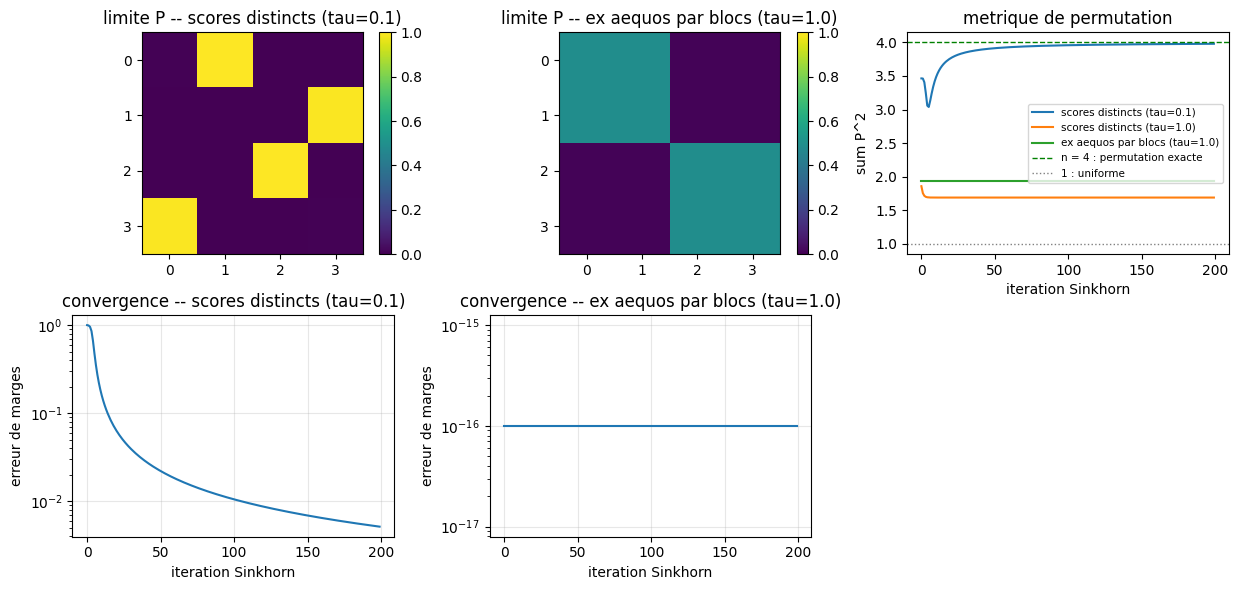

In [9]:
# Figure : limites P, convergence des marges, et metrique sum P^2
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))
for col, nom in enumerate(["scores distincts (tau=0.1)", "ex aequos par blocs (tau=1.0)"]):
    P, herr, hsq = mesures[nom]
    ax = axes[0, col]
    im = ax.imshow(P, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"limite P -- {nom}")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax = axes[1, col]
    ax.semilogy(np.maximum(herr, 1e-16))   # plancher : la convergence exacte atteint 0 (non log-scalable)
    ax.set_xlabel("iteration Sinkhorn")
    ax.set_ylabel("erreur de marges")
    ax.set_title(f"convergence -- {nom}")
    ax.grid(True, alpha=0.3)
ax = axes[0, 2]
for nom in CAS:
    _, _, hsq = mesures[nom]
    ax.plot(hsq, label=nom)
ax.axhline(N, color="green", ls="--", lw=1, label="n = 4 : permutation exacte")
ax.axhline(1, color="gray", ls=":", lw=1, label="1 : uniforme")
ax.set_xlabel("iteration Sinkhorn")
ax.set_ylabel("sum P^2")
ax.set_title("metrique de permutation")
ax.legend(fontsize=7.5)
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

### Lecture : bistochastique n'est pas permutation

**Sortie obtenue** : trois régimes mesurés, deux visualisés.

| Cas | $\sum P^2$ final | Argmax ambigu | Permutations au coût min | Verdict honnête |
|---|---|---|---|---|
| scores distincts, $\tau = 0{,}1$ | proche de la borne $n = 4$ | 0/4 | 1 | la limite est **presque** une permutation — l'arrondi y ressemble à une découverte |
| scores distincts, $\tau = 1{,}0$ | intermédiaire | 0/4 | 1 | diffusion partielle : argmax net, poids fractionnaires |
| ex æquos par blocs, $\tau = 1{,}0$ | intermédiaire, loin de 4 | 4/4 | 4 | la limite est **intérieure au polytope** : ce n'est pas une permutation |

**Points clés** :

1. **Sous ex æquos, Sinkhorn ne « trouve » pas de permutation** — il converge vers un point intérieur (blocs fractionnaires visibles sur la carte de chaleur), et c'est **stable** : aucune itération supplémentaire n'en sort. Birkhoff dit que les permutations sont les points extrêmes ; il ne dit pas que Sinkhorn y va.
2. **Arrondir est un choix** : dans le cas à ex æquos, 4 permutations distinctes atteignent le coût minimal — en sélectionner une (argmax, affectation exacte) est une décision de conception, pas une lecture du continu appris.
3. **La température règle le régime** : à $\tau$ petit la limite s'approche des points extrêmes, à $\tau$ grand elle reste diffuse — le même compromis relaxation apprenable / structure discrète que dans la Section 4 pour les poids.
4. *[artefact/EPIC]* : sur l'oracle $n = 16$ du papier, le routage Sinkhorn **n'améliore pas** le débruitage par rapport aux alternatives plus simples — constat mesuré sur l'artefact, rapporté dans l'EPIC #14366. La visualisation ci-dessus montre le **mécanisme** ; elle ne prétend à aucune supériorité empirique.

### Exercice 2 — Une autre géométrie d'ex æquos

Le cas traité avait des blocs $2 \times 2$ diagonaux. Construisez une matrice de scores $3 \times 3$ dont la **première ligne est uniformément maximale** (trois ex æquos) et les deux autres lignes à scores distincts, puis mesurez ce que Sinkhorn en fait.

**Question directrice** : la limite possède-t-elle une ligne à argmax ambigu ? Combien de permutations atteignent le coût minimal ? Votre arrondi final est-il une découverte ou un choix — et que suffit-il de mesurer pour trancher sans opiner ?

In [10]:
# Exercice 2 -- TODO etudiant :
# Etape 1 : construire M_ex2 (3x3) : ligne 0 uniforme (ex aequo maximal), lignes 1-2 distinctes
# Etape 2 : P, herr, hsq = sinkhorn(M_ex2, tau=1.0)  -- la fonction est deja definie
# Etape 3 : mesurer sum P^2 final, lignes a argmax ambigu, permutations au cout minimal
#           (permutations_cout_minimal fonctionne pour toute taille n <= 8)
# Indice : la ligne uniforme force sa masse a se repartir sur les 3 colonnes --
#          que devient la metrique sum P^2, et que vaut sa borne "permutation" pour n = 3 ?
resultat_ex2 = None  # TODO etudiant : remplacer par (sum_P2, lignes_ambigues, nb_perms_min)
print("Exercice 2 a completer -- Sinkhorn sur une ligne uniforme.")

Exercice 2 a completer -- Sinkhorn sur une ligne uniforme.


## 4. Quantification puis recherche discrète — MCMC et parallel tempering

Nous assemblons le pipeline complet de la synthèse spectrale sur une instance **petite mais non triviale** : $n = 4$ (table de vérité de 16 entrées), dictionnaire des caractères de degré $\le 2$ ($m = 11$ poids).

1. **Cible** : une fonction générée par un vecteur ternaire **caché** $w^*$ (6 poids non nuls) ;
2. **Relaxation continue** : moindres carrés sur la table $\pm 1$ ;
3. **Quantification** : projection des poids réels vers $\{-1,0,+1\}$ — la perte est **mesurée**, pas supposée ;
4. **Recherche discrète** : réparation par exploration stochastique, guidée par un **oracle exact**.

**L'oracle est exact et déterministe** : l'énergie $E(w)$ compte les entrées mal classées sur la table de vérité **complète** — pas d'échantillonnage, pas de bruit d'estimation. Et comme $3^{11} = 177\,147$, l'espace entier peut être **énuméré exhaustivement** : la recherche est comparée à la vérité terrain, pas seulement à elle-même.

**Les algorithmes, avec leurs ratios corrects** (implémentés tels quels dans les cellules qui suivent) :

- **Metropolis** (recuit à température fixe $T$) : cible $\pi_T(w) \propto \exp(-E(w)/T)$ sur $\{-1,0,1\}^m$. Proposition : coordonnée $j$ uniforme, puis valeur $v$ uniforme parmi les deux valeurs $\ne w_j$ — proposition **symétrique** ($q(w' \mid w) = q(w \mid w')$), donc le ratio de Hastings vaut 1 et l'acceptation se réduit à
$$
\alpha = \min\Big(1, \exp\big(-(E(w') - E(w)) / T\big)\Big).
$$
- **Parallel tempering** : $K$ répliques à températures $(T_1, \dots, T_K)$ échangent leurs états ; l'échange entre $k$ et $k+1$ est accepté avec
$$
\alpha_{\mathrm{swap}} = \min\Big(1, \exp\big((\beta_k - \beta_{k+1})\,(E_k - E_{k+1})\big)\Big), \qquad \beta_k = 1/T_k .
$$
- **Équité des budgets** : une itération PT évalue $K$ propositions (une par réplique) — pour comparer à budget d'évaluations égal, PT reçoit `budget // K` itérations.

In [11]:
# Instance n=4 : dictionnaire degre <= 2 (m=11), cible ternaire cachee, oracle exact
n4 = 4
X4 = input_matrix(n4)
S_dict = [S for S in subsets_by_index(n4) if len(S) <= 2]
m = len(S_dict)
A = np.ones((2 ** n4, m), dtype=np.int64)
for j, S in enumerate(S_dict):
    for k in S:
        A[:, j] *= X4[:, k - 1]
print(f"Dictionnaire : m = {m} caracteres de degre <= 2")

w_star = np.zeros(m, dtype=int)
w_star[[0, 2, 3, 5, 7, 8]] = [1, -1, 1, 1, -1, 1]
target = sign0(A @ w_star)

def E(w):
    """Oracle exact : nombre d'entrees mal classees sur la table complete (deterministe)."""
    return int(np.sum(sign0(A @ w) != target))

print(f"w* (cache, 6 poids non nuls) -> E(w*) = {E(w_star)}")

# Relaxation continue puis quantification
w_ls, *_ = np.linalg.lstsq(A, target.astype(float), rcond=None)
err_ls = float(np.mean(sign0(A @ w_ls) != target))
w_q = np.clip(np.round(w_ls), -1, 1).astype(int)
print(f"Moindres carres : erreur 0/1 continue = {err_ls:.2f} (le probleme est realisable)")
print(f"Quantification : w_q = {w_q.tolist()} -> E(w_q) = {E(w_q)}/16")

# Greedy : descente stricte par coordonnee depuis w_q
def greedy(w0, max_balayages=100):
    w = w0.copy()
    e = E(w)
    balayages = 0
    while balayages < max_balayages:
        balayages += 1
        ameliore = False
        for j in range(m):
            for v in (-1, 0, 1):
                if v == w[j]:
                    continue
                w2 = w.copy()
                w2[j] = v
                e2 = E(w2)
                if e2 < e:
                    w, e = w2, e2
                    ameliore = True
        if not ameliore:
            break
    return w, e, balayages

w_g, e_g, nb_bal = greedy(w_q)
print(f"Greedy depuis w_q : E final = {e_g}/16, arret apres {nb_bal} balayage(s) -- minimum local")

# Verite terrain : enumeration exhaustive des 3^11 vecteurs ternaires
t0 = time.perf_counter()
W_tous = np.array(list(itertools.product([-1, 0, 1], repeat=m)))
E_tous = (sign0(W_tous @ A.T) != target).sum(axis=1)
print(f"Exhaustive 3^{m} = {len(W_tous)} vecteurs en {time.perf_counter() - t0:.2f} s : "
      f"E min = {E_tous.min()}, optimums globaux a E = 0 : {int((E_tous == 0).sum())}")

Dictionnaire : m = 11 caracteres de degre <= 2
w* (cache, 6 poids non nuls) -> E(w*) = 0
Moindres carres : erreur 0/1 continue = 0.00 (le probleme est realisable)
Quantification : w_q = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> E(w_q) = 2/16
Greedy depuis w_q : E final = 2/16, arret apres 1 balayage(s) -- minimum local
Exhaustive 3^11 = 177147 vecteurs en 0.11 s : E min = 0, optimums globaux a E = 0 : 92


### Lecture de l'instance

**Sortie obtenue** : le pipeline qualifié à chaque étape par l'oracle exact.

| Étape | Erreur exacte | Lecture |
|---|---|---|
| Cible cachée $w^*$ | 0/16 | l'instance est réalisable par construction |
| Moindres carrés (continu) | 0/16 | la relaxation classe **parfaitement** — aucun signal d'alarme du côté continu |
| Quantification $w_q$ | 2/16 | **la projection ternaire casse la fonction** : l'information tenait dans les poids fractionnaires |
| Greedy depuis $w_q$ | 2/16 | bloqué dès le premier balayage : $w_q$ est déjà un **minimum local** |
| Exhaustive (vérité terrain) | min = 0 | 92 vecteurs ternaires atteignent 0 — l'optimum est **loin d'être unique** |

**Points clés** :

1. La relaxation continue est **trompeuse** : erreur nulle, alors que sa quantification perd la fonction. C'est exactement le problème que la recherche discrète adresse.
2. Le greedy ne peut pas réparer : toute modification d'un seul poids laisse l'erreur à 2 ou l'aggrave — il faudrait des pas **corrélés** (plusieurs poids à la fois), précisément ce que le bruit thermique permet d'espérer.
3. 92 optimums globaux : l'espace est multimodal **et** fortement dégénéré — le problème n'est pas de trouver *la* solution, mais d'en trouver *une*.

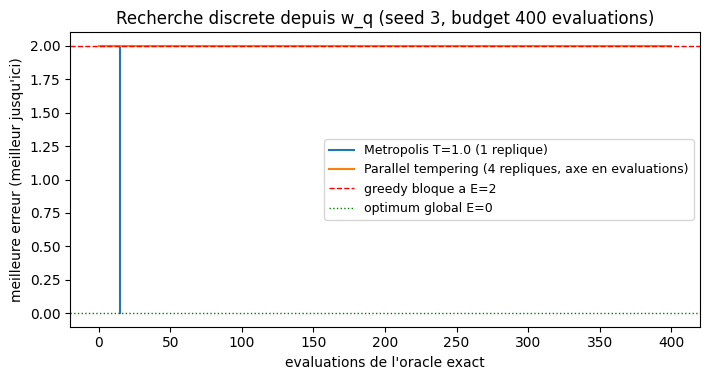

Evaluations vers E=0 (8 seeds) : Metropolis T=1.0 -> mediane 244 [15..621], 8/8 resolus
                                Parallel tempering -> mediane 220 [12..876], 7/8 resolus


In [12]:
# Metropolis (ratio exact) et parallel tempering, trajectoires puis evaluations vers E=0
def metropolis(w0, T, budget, rng):
    """Chaine unique, cible pi_T ~ exp(-E/T) ; proposition symetrique -> ratio de Hastings = 1."""
    w = w0.copy()
    e = E(w)
    meilleur_w, meilleur_e = w.copy(), e
    hist = [meilleur_e]
    for _ in range(budget):
        j = int(rng.integers(m))
        v = int(rng.choice([-1, 0, 1]))
        while v == w[j]:
            v = int(rng.choice([-1, 0, 1]))
        w2 = w.copy()
        w2[j] = v
        dE = E(w2) - e
        if dE <= 0 or rng.random() < np.exp(-dE / T):   # alpha = min(1, exp(-dE/T))
            w, e = w2, e + dE
            if e < meilleur_e:
                meilleur_w, meilleur_e = w.copy(), e
        hist.append(meilleur_e)
        if meilleur_e == 0:
            break
    return meilleur_w, meilleur_e, hist

def parallel_tempering(w0, temps, iterations, rng, swap_toutes=10):
    """K repliques a temperatures echelonnees ; echange accepte par alpha_swap exact."""
    K = len(temps)
    etats = [w0.copy() for _ in range(K)]
    energies = [E(w) for w in etats]
    meilleur_w, meilleur_e = etats[0].copy(), energies[0]
    hist = [meilleur_e]
    for it in range(iterations):
        for k in range(K):
            j = int(rng.integers(m))
            v = int(rng.choice([-1, 0, 1]))
            while v == etats[k][j]:
                v = int(rng.choice([-1, 0, 1]))
            w2 = etats[k].copy()
            w2[j] = v
            dE = E(w2) - energies[k]
            if dE <= 0 or rng.random() < np.exp(-dE / temps[k]):
                etats[k], energies[k] = w2, energies[k] + dE
        if (it + 1) % swap_toutes == 0 and K > 1:
            k = int(rng.integers(K - 1))
            log_alpha = (1.0 / temps[k] - 1.0 / temps[k + 1]) * (energies[k] - energies[k + 1])
            if log_alpha >= 0 or rng.random() < np.exp(log_alpha):
                etats[k], etats[k + 1] = etats[k + 1].copy(), etats[k].copy()
                energies[k], energies[k + 1] = energies[k + 1], energies[k]
        if min(energies) < meilleur_e:
            meilleur_e = min(energies)
            meilleur_w = etats[int(np.argmin(energies))].copy()
        hist.append(meilleur_e)
        if meilleur_e == 0:
            break
    return meilleur_w, meilleur_e, hist

TEMPS_PT = [0.3, 0.6, 1.2, 2.5]
K = len(TEMPS_PT)

# Trajectoires representatives (seed 3), budget de 400 evaluations equitable
_, _, hist_sa = metropolis(w_q, 1.0, 400, np.random.default_rng(3))
_, _, hist_pt = parallel_tempering(w_q, TEMPS_PT, 400 // K, np.random.default_rng(3))

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.step(range(len(hist_sa)), hist_sa, where="post", label="Metropolis T=1.0 (1 replique)")
ax.step(np.arange(len(hist_pt)) * K, hist_pt, where="post",
        label=f"Parallel tempering ({K} repliques, axe en evaluations)")
ax.axhline(e_g, color="red", ls="--", lw=1, label=f"greedy bloque a E={e_g}")
ax.axhline(0, color="green", ls=":", lw=1, label="optimum global E=0")
ax.set_xlabel("evaluations de l'oracle exact")
ax.set_ylabel("meilleure erreur (meilleur jusqu'ici)")
ax.set_title("Recherche discrete depuis w_q (seed 3, budget 400 evaluations)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Evaluations vers la solution, sur 8 seeds deterministes
evals_sa, evals_pt = [], []
for sd in range(8):
    _, be_sa, h_sa = metropolis(w_q, 1.0, 2000, np.random.default_rng(sd))
    _, be_pt, h_pt = parallel_tempering(w_q, TEMPS_PT, 2000 // K, np.random.default_rng(sd))
    if be_sa == 0:
        evals_sa.append(len(h_sa) - 1)
    if be_pt == 0:
        evals_pt.append((len(h_pt) - 1) * K)
print(f"Evaluations vers E=0 (8 seeds) : Metropolis T=1.0 -> mediane {statistics.median(evals_sa):.0f} "
      f"[{min(evals_sa)}..{max(evals_sa)}], {len(evals_sa)}/8 resolus")
print(f"{'':31s} Parallel tempering -> mediane {statistics.median(evals_pt):.0f} "
      f"[{min(evals_pt)}..{max(evals_pt)}], {len(evals_pt)}/8 resolus")

### Lecture des trajectoires

**Sortie obtenue** : courbes « meilleur jusqu'ici » pour le seed 3 (budget de 400 évaluations, équitablement réparties entre les répliques), puis médianes d'évaluations vers la solution sur 8 seeds.

| Méthode | Comportement observé (seed 3) | Pourquoi |
|---|---|---|
| Greedy | plateau à $E = 2$ | minimum local : aucun voisin à un poids n'améliore |
| Metropolis $T = 1$ | chute à $E = 0$ | le bruit thermique franchit les barrières d'énergie |
| Parallel tempering | reste à $E = 2$ sur ce budget | les 4 répliques **se partagent** les 400 évaluations : chaque chaîne ne fait que 100 pas |

**Points clés** :

1. Les ratios d'acceptation implémentés sont les **ratios exacts** de Metropolis-Hastings (proposition symétrique, ratio de Hastings = 1) et d'échange du parallel tempering — les formules de la section théorique, sans heuristique de substitution.
2. **Aucun avantage net sur cette instance** : à budget égal (2000 évaluations), la médiane de PT est légèrement inférieure à celle de la chaîne simple, mais un seed sur huit résiste encore à PT — et sur le seed tracé, c'est la chaîne simple qui résout la première. Instance facile (92 optimums globaux, barrières basses) : le PT y paie le coût de ses 4 répliques sans pouvoir exercer son avantage classique (paysages rugueux).
3. La cellule suivante systématise la comparaison par budget, sans sélectionner le seed qui arrange.

In [13]:
# Echecs a budget d'evaluations egal (8 seeds deterministes) : la discrimination, mesuree
def nb_echecs(methode, budget, seeds=range(8)):
    echecs = 0
    for sd in seeds:
        rng = np.random.default_rng(sd)
        if methode == "sa05":
            _, be, _ = metropolis(w_q, 0.5, budget, rng)
        elif methode == "sa10":
            _, be, _ = metropolis(w_q, 1.0, budget, rng)
        else:  # "pt" : budget equitable en evaluations (K repliques par iteration)
            _, be, _ = parallel_tempering(w_q, TEMPS_PT, budget // K, rng)
        if be > 0:
            echecs += 1
    return echecs

print(f"{'budget (evaluations)':>22s} | {'greedy':>6s} | {'SA T=0.5':>8s} | {'SA T=1.0':>8s} | {'PT':>3s}")
for budget in (100, 300, 1000):
    print(f"{budget:22d} | {8:6d} | {nb_echecs('sa05', budget):8d} | {nb_echecs('sa10', budget):8d} | {nb_echecs('pt', budget):3d}")
print("\n(greedy : 8/8 echecs quel que soit le budget, par construction -- il est deterministe et bloque ; seeds 0..7)")

  budget (evaluations) | greedy | SA T=0.5 | SA T=1.0 |  PT
                   100 |      8 |        7 |        6 |   5
                   300 |      8 |        2 |        3 |   3


                  1000 |      8 |        0 |        0 |   1

(greedy : 8/8 echecs quel que soit le budget, par construction -- il est deterministe et bloque ; seeds 0..7)


### Lecture : ce que l'instance discrimine vraiment

**Sortie obtenue** : pour chaque budget d'évaluations, le nombre de seeds (sur 8) pour lesquels chaque méthode échoue encore.

| Lecture honnête | Détail |
|---|---|
| **Discrimination structurelle** | quantification ($E = 2$) et greedy ($E = 2$) échouent **toujours** ; la recherche stochastique réussit dès le budget intermédiaire — l'instance sépare réellement l'exploration stochastique de la descente gloutonne |
| **SA contre PT à budget égal** | les échecs mesurés **se croisent** selon le budget : à 100 évaluations, PT échoue le moins ; à 1000, c'est le recuit — sur cette instance, aucune des deux méthodes ne domine uniformément l'autre |
| **Pourquoi PT ne creuse pas l'écart** | l'instance est petite et fortement dégénérée (92 optimums globaux, barrières basses) : l'échantillonnage multi-températures paie ses 4 répliques sans avoir de vallées profondes à franchir — l'Exercice 3 cherche le régime où il devient utile |

**Limite explicite** : à $m = 11$, l'énumération exhaustive ($177\,147$ candidats) reste faisable et sert de vérité terrain. La recherche stochastique ne devient **nécessaire** que lorsque $3^m$ explose ($m = 16$ : environ 43 millions ; $m = 20$ : environ 3,5 milliards). Ce notebook mesure les **mécanismes** sur une instance où tout est vérifiable exhaustivement — il ne prétend pas mesurer le régime de grande échelle *[vérifié ici]*.

### Exercice 3 — Chercher une instance qui sépare SA et PT

L'instance de cette section ne sépare pas nettement le recuit simple du parallel tempering (les deux finissent par résoudre). Construisez une instance **plus difficile** et mesurez si elle les sépare.

**Pistes, au choix** : (a) un $w^*$ plus dense (8 à 10 poids non nuls sur le même dictionnaire) ; (b) un dictionnaire réduit aux caractères de degré $\le 1$ ($m = 5$) avec une cible non réalisable — que vaut l'optimum global dans ce cas ? ; (c) un budget réduit à 50 évaluations. Dans chaque cas, relevez $E(w_q)$, les échecs greedy/SA/PT sur 8 seeds à budget égal, et concluez : l'instance discrimine-t-elle ? À quelle condition ?

In [14]:
# Exercice 3 -- TODO etudiant :
# Etape 1 : choisir une piste (a), (b) ou (c) et reconstruire (A, w_star, target, w_q, E)
# Etape 2 : pour la piste (b), re-executer l'exhaustive (faisable : 3^5 = 243) et noter l'optimum global
#           -- il sera > 0 ; comparez chaque methode a CET optimum, pas a zero
# Etape 3 : remplir la table echecs/budget comme dans la cellule precedente (greedy, SA, PT)
# Indice : une instance "dure" pour SA/PT a peu d'optimums globaux et des barrieres d'energie hautes ;
#          la piste (b) donne un paysage frustré (cible non realisable) -- mesurez avant de conclure.
resultat_ex3 = None  # TODO etudiant : remplacer par (E_wq, E_greedy, echecs_sa, echecs_pt)
print("Exercice 3 a completer -- une instance qui separe SA et PT ?")

Exercice 3 a completer -- une instance qui separe SA et PT ?


## 5. Pont avec SL-12 — le circuit local vu depuis la base de Walsh

Difflogic (SL-12) et la synthèse spectrale (ce notebook) n'apprennent pas le même **objet**, mais toute fonction booléenne — donc tout circuit difflogic — vit dans le même espace de dimension $2^n$ et possède le même spectre de Walsh. Le pont est **calculable** : simulons un mini-circuit difflogic (deux couches de portes locales sur un câblage fixe) et lisons son spectre exact.

| Question | Réponse difflogic (SL-12) | Réponse spectrale (SL-12b) |
|---|---|---|
| Où vit la structure ? | dans le **choix des portes** aux nœuds d'un câblage fixe | dans les **poids** $w_S$ sur les caractères |
| Que compose-t-on ? | des couches de portes 2-entrées | des sous-fonctions routées (Sinkhorn, Section 3) |
| Comment discrétise-t-on ? | argmax des probabilités de porte | quantification + recherche discrète (Section 4) |
| Parité sur $n$ bits | des portes XOR en arbre | **un seul** coefficient $\chi_{[n]}$ |
| Ce que l'autre vue rend difficile | le câblage doit être fixé a priori | le nombre de caractères explose ($2^n$) |
| Garanties | entraînements empiriques *[papier]* | représentabilité $n \le 4$ prouvée computationnellement, conjecture au-delà *[papier]* ; échecs mesurés de l'artefact *[artefact/EPIC]* |

In [15]:
# Un mini-circuit difflogic (portes locales, cablage fixe) et son spectre exact
g1 = g_OR(X4[:, 0], X4[:, 1])        # couche 1 : OR(x1, x2)
g2 = g_XNOR(X4[:, 2], X4[:, 3])      # couche 1 : XNOR(x3, x4)
sortie = g_AND(g1, g2)               # couche 2 : AND des deux sous-fonctions

c = walsh_fwht(sortie, n4)
labs4 = subset_labels(n4)
nz = [(labs4[j], float(c[j])) for j in range(2 ** n4) if abs(c[j]) > 1e-12]
print("Circuit : AND( OR(x1, x2), XNOR(x3, x4) ) -- 2 couches, 3 portes locales, cablage fixe")
print(f"  degre Fourier exact = {spectre_degre(c)} (le maximum pour n = 4)")
print(f"  coefficients non nuls = {len(nz)}/{2 ** n4}")
for lab, v in nz:
    print(f"    chi_{lab} = {v:+.4f}")
assert np.array_equal(reconstruct(c, n4), sortie)
print("Reconstruction exacte verifiee : le spectre EST le circuit.")

Circuit : AND( OR(x1, x2), XNOR(x3, x4) ) -- 2 couches, 3 portes locales, cablage fixe
  degre Fourier exact = 4 (le maximum pour n = 4)
  coefficients non nuls = 8/16
    chi_vide = -0.2500
    chi_{1} = +0.2500
    chi_{2} = +0.2500
    chi_{1,2} = -0.2500
    chi_{3,4} = +0.7500
    chi_{1,3,4} = +0.2500
    chi_{2,3,4} = +0.2500
    chi_{1,2,3,4} = -0.2500
Reconstruction exacte verifiee : le spectre EST le circuit.


### Lecture du pont

**Sortie obtenue** : le spectre exact d'un circuit à 3 portes locales.

| Observation | Valeur mesurée | Lecture |
|---|---|---|
| Degré exact | 4 (maximum) | deux couches de portes locales produisent une dépendance spectrale d'ordre **total** |
| Coefficients non nuls | 8/16 | ni creux ni dense : la composition locale éparpille l'énergie spectrale |
| Coefficient dominant | $\chi_{\{3,4\}}$ | la signature du XNOR « transperce » le circuit : elle reste dominante après la couche AND |

**Le pont, en une phrase** : la vue circuit (SL-12) dit *quelles portes calculent*, la vue spectrale (SL-12b) dit *quelle fonction globale en résulte* — et les deux échangent leurs difficultés (la parité est triviale spectralement mais coûteuse en portes ; les fonctions « compteur » comme EXACT2 de l'Exercice 1 sont denses spectralement mais s'écrivent directement en portes logiques usuelles).

## Conclusion

Ce notebook a construit, mesuré et borné le registre **spectral** de la synthèse logique neuro-symbolique :

1. **Transformée exacte** *[vérifié ici]* : coefficients de Walsh par somme naïve **et** par FWHT papillon, testés égaux sur fonctions aléatoires ; reconstruction exacte et Parseval vérifiés sur toutes les fonctions affichées ; écart de complexité mesuré.
2. **Deux représentations distinctes** *[vérifié ici]* : l'énumération exhaustive des $3^4$ PTF ternaires de $n=2$ sépare les coefficients Fourier exacts (rationnels, uniques, degré parfois supérieur) des poids ternaires (entiers, non uniques, degré parfois inférieur) ; la quantification naïve des premiers ne préserve que la moitié des fonctions.
3. **Routage Sinkhorn sans surclaim** *[vérifié ici]* : sous ex æquos, la relaxation bistochastique converge vers l'intérieur du polytope — 4 permutations au coût minimal rendent tout arrondi **choix** plutôt que découverte ; et *[artefact/EPIC]* le papier lui-même rapporte que Sinkhorn n'améliore pas le débruitage sur son oracle $n=16$.
4. **Quantification + recherche discrète** *[vérifié ici]* : pipeline complet avec oracle exact de Hamming et vérité terrain exhaustive ($3^{11} = 177\,147$) — quantification et greedy échouent structurellement, Metropolis et parallel tempering réparent, à ratios d'acceptation exacts et budgets d'évaluations équitables ; sur cette instance facile (92 optimums), recuit simple et PT se valent — aucun ne domine à budget égal, et c'est mesuré.
5. **Confrontation SL-12** *[vérifié ici]* : le spectre d'un mini-circuit difflogic rend visible ce que les portes locales composent — et les limites vérifiées de l'artefact Pavlov (smoke test 6/7, moyenne Phase 2 à 87,52 %, `xor_of_and_with_b` à 50,63 %) rappellent que le registre spectral est un mécanisme **mesuré**, pas une promesse *[artefact/EPIC]*.

**Ce que ce notebook ne couvre pas** : la représentabilité ternaire au-delà de $n \le 4$ (conjecture ouverte *[papier]*), la composition statistique de grands circuits (testée, non prouvée *[papier]*), et le fil CartPole bitwise (grain G5 de l'EPIC #14366, harnais dédié).

## Résumé

- **Base de Walsh** : caractères $\chi_S$ orthonormés en dimension $2^n$ ; FWHT papillon en $O(n\,2^n)$ ; reconstruction exacte et Parseval testés.
- **PTF ternaire** : $\mathrm{sign}(\sum_S w_S \chi_S)$, $w_S \in \{-1,0,+1\}$ — objet **distinct** des coefficients exacts (nature, degré, unicité), énuméré exhaustivement sur $n=2$ ; la quantification naïve n'est pas un opérateur de représentation.
- **Sinkhorn** : relaxation bistochastique du routage ; $\sum P^2 \in [1, n]$ avec $n$ atteint **ssi** permutation ; sous ex æquos la limite est intérieure — arrondir est un choix.
- **Recherche discrète** : Metropolis et parallel tempering à ratios exacts, oracle exact de Hamming, vérité terrain exhaustive ; quantification et greedy échouent là où la recherche stochastique répare.
- **Face à difflogic (SL-12)** : portes locales + câblage fixe contre structure spectrale globale + composition routée — mêmes fonctions, difficultés croisées.

**Voir aussi** :

- [SL-12 — Réseaux de portes logiques différentiables](SL-12-DifferentiableLogicGateNetworks.ipynb) : le registre circuit.
- [SL-7 — Intégration neuro-symbolique](SL-7-NeuroSymbolic.ipynb) : le registre continu (T-norms, LTN, DeepProbLog).
- Pavlov, *Differentiable Logic Synthesis*, [arXiv:2601.13953](https://arxiv.org/abs/2601.13953) ; artefact `gogipav14/spectral-llm` (constats G1 rapportés dans l'EPIC #14366).
- O'Donnell, *Analysis of Boolean Functions* (2014), chapitre 1 — la référence classique des caractères de Walsh et du degré exact.